# UMI summary


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
SUMMARY_DIR = Path("/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/umi")

summary_files = sorted(SUMMARY_DIR.glob("*_umi_summary.txt"))
print(f"Found {len(summary_files)} summary files")
summary_files[:3]


Found 19 summary files


[PosixPath('/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/umi/GFB-64245_DMF5CDR3bGIG012xnegative_umi_summary.txt'),
 PosixPath('/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/umi/GFB-64246_DMF5CDR3bGIG032xnegative_umi_summary.txt'),
 PosixPath('/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/umi/GFB-64247_DMF5CDR3bGIG042xnegative_umi_summary.txt')]

In [3]:
import re
from pathlib import Path
import pandas as pd

def norm_line(s: str) -> str:
    # normalize weird whitespace and carriage returns
    s = s.replace("\r", "")
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def last_int(s: str, default=None):
    nums = re.findall(r"\d+", s)
    return int(nums[-1]) if nums else default

KEYS = {
    "Total reads processed:": "total_reads",
    "Reads too short for spacer+UMI+anchor (dropped):": "dropped_too_short",
    "Reads with no anchor found (dropped):": "dropped_no_anchor",
    "Reads with anchor at invalid position (dropped):": "dropped_anchor_invalid",
    "Reads with empty insert after anchor (dropped):": "dropped_empty_insert",
    "Reads contributing to consensus UMIs:": "reads_consensus",
    "Reads in singleton UMIs:": "reads_singletons",
    "Total UMIs detected:": "total_umis",
    "UMIs with >= 2 reads (consensus):": "umis_ge2",
    "UMIs with 1 read (singletons kept):": "umis_singletons",
}

def parse_umi_summary(path: Path) -> dict:
    out = {"sample": path.stem.replace("_umi_summary", "")}

    # defaults
    for k in ["dropped_too_short","dropped_no_anchor","dropped_anchor_invalid","dropped_empty_insert",
              "reads_consensus","reads_singletons"]:
        out[k] = 0

    txt = path.read_text(errors="replace")
    for raw in txt.splitlines():
        ln = norm_line(raw)
        if not ln:
            continue
        for prefix, col in KEYS.items():
            # use "in" to be robust to leading/trailing junk, but keep it specific
            if prefix in ln:
                out[col] = last_int(ln, out.get(col, 0))

    out["dropped_total"] = (
        out["dropped_too_short"] + out["dropped_no_anchor"] +
        out["dropped_anchor_invalid"] + out["dropped_empty_insert"]
    )

    if out.get("total_reads") is not None:
        out["kept_after_anchor"] = out["total_reads"] - out["dropped_total"]
        out["reads_other_kept"] = out["kept_after_anchor"] - (out["reads_consensus"] + out["reads_singletons"])
    else:
        out["kept_after_anchor"] = None
        out["reads_other_kept"] = None

    return out

SUMMARY_DIR = Path("/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/umi")
files = sorted(SUMMARY_DIR.glob("*_umi_summary.txt"))

df_sum = pd.DataFrame([parse_umi_summary(p) for p in files])
df_sum[["sample","total_reads","dropped_no_anchor","dropped_anchor_invalid","dropped_total","reads_consensus","reads_singletons"]].head(10)


,sample,total_reads,dropped_no_anchor,dropped_anchor_invalid,dropped_total,reads_consensus,reads_singletons
0,GFB-64245_DMF5CDR3bGIG012xnegative,20559922,12897924,14823,12912747,7041115,606060
1,GFB-64246_DMF5CDR3bGIG032xnegative,9522581,4553659,10599,4564258,4499254,459069
2,GFB-64247_DMF5CDR3bGIG042xnegative,31921097,7821877,47058,7868935,23133052,919110
3,GFB-64248_DMF5CDR3bGIG052xnegative,13088994,6029921,14135,6044056,6525551,519387
4,GFB-64249_DMF5CDR3bDRG012xnegative,10386374,3381336,15061,3396397,6493897,496080
5,GFB-64250_DMF5CDR3bDRG042xnegative,6553544,3063964,7486,3071450,3116728,365366
6,GFB-64251_DMF5CDR3bGIG011xpositive,3381255,1452744,3923,1456667,1553364,371224
7,GFB-64252_DMF5CDR3bGIG031xpositive,7289425,3224692,8296,3232988,3705245,351192
8,GFB-64253_DMF5CDR3bGIG041xpositive,544743,290235,572,290807,125550,128386
9,GFB-64254_DMF5CDR3bGIG051xpositive,9577580,2739200,13812,2753012,6314074,510494


In [4]:
plot_cols = [
    "dropped_too_short",
    "dropped_no_anchor",
    "dropped_anchor_invalid",
    "dropped_empty_insert",
    "reads_consensus",
    "reads_singletons",
    "reads_other_kept",
]

# Replace NaN with 0 for plotting
df_plot = df_sum.copy()
df_plot[plot_cols] = df_plot[plot_cols].fillna(0)

# sanity check
df_plot["stack_sum"] = df_plot[plot_cols].sum(axis=1)
df_plot["difference_vs_total"] = df_plot["total_reads"] - df_plot["stack_sum"]

df_plot[["sample","total_reads","stack_sum","difference_vs_total"]].head()


,sample,total_reads,stack_sum,difference_vs_total
0,GFB-64245_DMF5CDR3bGIG012xnegative,20559922,20559922,0
1,GFB-64246_DMF5CDR3bGIG032xnegative,9522581,9522581,0
2,GFB-64247_DMF5CDR3bGIG042xnegative,31921097,31921097,0
3,GFB-64248_DMF5CDR3bGIG052xnegative,13088994,13088994,0
4,GFB-64249_DMF5CDR3bDRG012xnegative,10386374,10386374,0


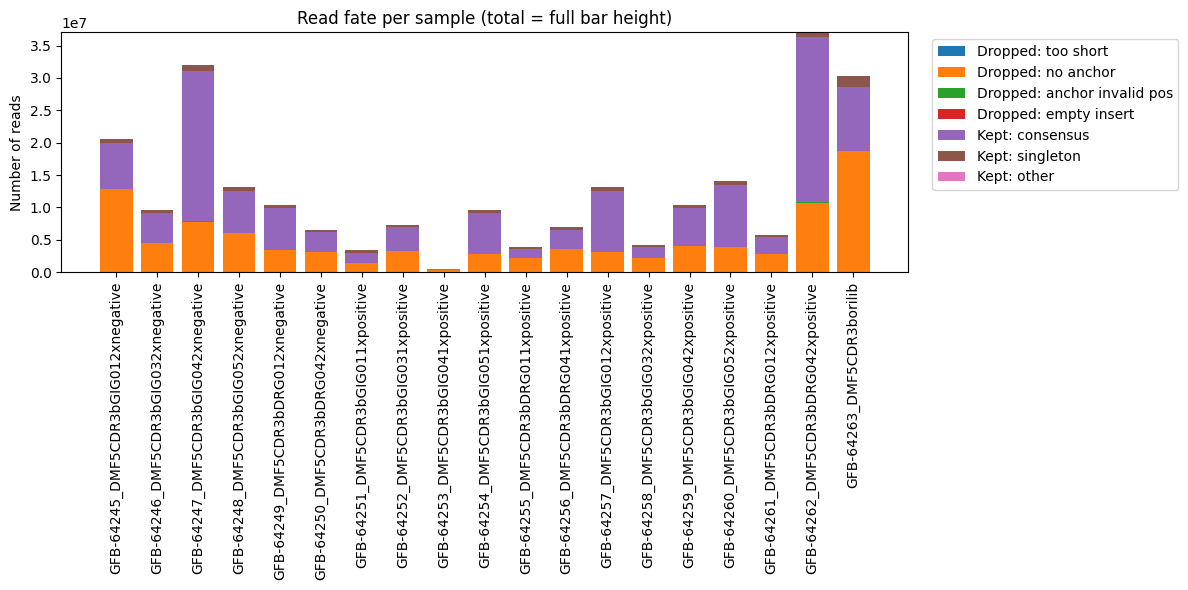

In [5]:
import matplotlib.pyplot as plt

labels = {
    "dropped_too_short": "Dropped: too short",
    "dropped_no_anchor": "Dropped: no anchor",
    "dropped_anchor_invalid": "Dropped: anchor invalid pos",
    "dropped_empty_insert": "Dropped: empty insert",
    "reads_consensus": "Kept: consensus",
    "reads_singletons": "Kept: singleton",
    "reads_other_kept": "Kept: other",
}

df_plot = df_plot.sort_values("sample")

fig, ax = plt.subplots(figsize=(max(12, 0.5 * len(df_plot)), 6))

bottom = None

for col in plot_cols:
    values = df_plot[col].values
    ax.bar(df_plot["sample"], values, bottom=bottom, label=labels[col])
    bottom = values if bottom is None else bottom + values

ax.set_ylabel("Number of reads")
ax.set_title("Read fate per sample (total = full bar height)")
ax.tick_params(axis="x", rotation=90)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


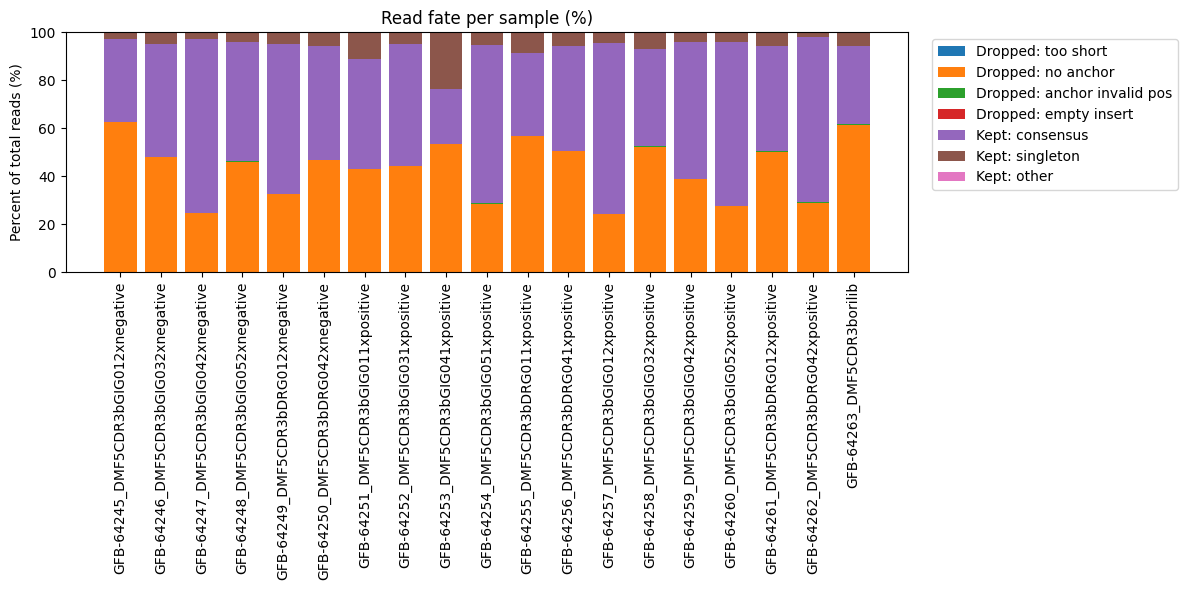

In [6]:
df_pct = df_plot.copy()
df_pct[plot_cols] = df_pct[plot_cols].div(df_pct["total_reads"], axis=0) * 100

fig, ax = plt.subplots(figsize=(max(12, 0.5 * len(df_pct)), 6))

bottom = None

for col in plot_cols:
    values = df_pct[col].values
    ax.bar(df_pct["sample"], values, bottom=bottom, label=labels[col])
    bottom = values if bottom is None else bottom + values

ax.set_ylabel("Percent of total reads (%)")
ax.set_ylim(0, 100)
ax.set_title("Read fate per sample (%)")
ax.tick_params(axis="x", rotation=90)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/umi/GFB-64259_DMF5CDR3bGIG042xpositive_consensus_qc.tsv"

df = pd.read_csv(file_path, sep="\t")

df.head()


,umi,n_reads,cons_len,nN,min_log_delta,median_log_delta,p10_log_delta
0,AATAATTTGGTG,43,116,0,240.606,453.062,392.818
1,CCGTAAATGCTT,5,116,0,25.995,48.880,40.314
2,AGGTTTATGAAG,6,116,0,22.606,62.773,50.853
3,ACTTGTTCAGGG,37,116,0,62.889,373.843,229.097
4,GTTAAGGTAAAG,5,116,0,33.217,51.657,41.926


In [2]:
length_counts = df["cons_len"].value_counts().sort_index()

length_counts


cons_len
75          1
76         11
77          1
78          7
79          9
80         45
81         14
82         21
83         43
84         27
85         54
86         73
87         38
88        322
89         88
90        177
91         53
92         86
93         40
94         87
95        128
96         92
97        280
98        111
99        158
100        57
101       106
102        99
103       117
104        81
105       129
106       150
107       131
108       112
109       206
110       261
111       408
112       318
113       347
114       539
115    258718
116    316913
117     33613
118     29812
119        16
Name: count, dtype: int64

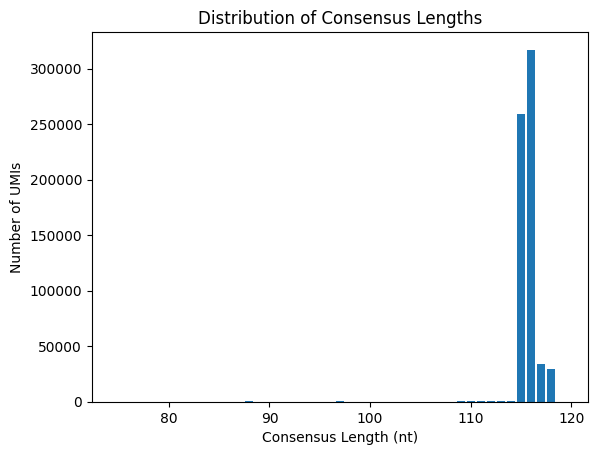

In [3]:
plt.figure()
plt.bar(length_counts.index, length_counts.values)

plt.xlabel("Consensus Length (nt)")
plt.ylabel("Number of UMIs")
plt.title("Distribution of Consensus Lengths")

plt.show()


In [4]:
reads_with_N = (df["nN"] > 0).sum()
total_reads = len(df)

print("Sequences with ≥1 N:", reads_with_N)
print("Total sequences:", total_reads)
print("Fraction:", reads_with_N / total_reads)

Sequences with ≥1 N: 51367
Total sequences: 644099
Fraction: 0.07975016263027888
